In [1]:
import torch
import torch.nn as nn
from torchvision import transforms, datasets
from torchvision.models import resnet50, ResNet50_Weights
from torch.utils.data import DataLoader

device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(device)

mps


In [3]:
import os

print(os.getcwd())
print(os.listdir())

/Users/aryanshinde/Projects/Eye Retiroscopy Hackathon
['IDRiD Dataset', '.DS_Store', 'FourSep.ipynb', 'Testing.ipynb', 'retinopathy_model.ipynb', 'retinopathy_best.pth', '.ipynb_checkpoints', 'archive.zip', 'retinopathy_cnn.pth', 'aptos2019-blindness-detection.zip', 'aptos2019-blindness-detection', 'SIH Frontend']


In [4]:
train_dir = "IDRiD Dataset/Train/images"
csv_path = "IDRiD Dataset/Train/annotations.csv"

In [9]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import pandas as pd
import os
from sklearn.model_selection import train_test_split

train_dir = "IDRiD/Train/images"
csv_path = "IDRiD/Train/annotations.csv"

df = pd.read_csv(csv_path)

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["Retinopathy grade"],
    random_state=42
)

print(len(train_df), len(val_df))

FileNotFoundError: [Errno 2] No such file or directory: 'IDRiD/Train/annotations.csv'

In [6]:
train_dir = "IDRiD Dataset/Train/images"
csv_path = "IDRiD Dataset/Train/annotations.csv"

In [8]:
import os

print(os.path.exists("IDRiD Dataset"))
print(os.listdir("IDRiD Dataset"))

True
['.DS_Store', 'Test', 'Train']


In [10]:
import os

for root, dirs, files in os.walk("IDRiD Dataset"):
    print(root)
    for f in files:
        if "annotation" in f.lower():
            print("   CSV:", f)

IDRiD Dataset
IDRiD Dataset/Test
   CSV: annotations.csv
IDRiD Dataset/Test/images
IDRiD Dataset/Train
   CSV: annotations.csv
IDRiD Dataset/Train/images
IDRiD Dataset/Train/.ipynb_checkpoints


In [11]:
import pandas as pd
import os

train_dir = "IDRiD Dataset/Train/images"
csv_path = "IDRiD Dataset/Train/annotations.csv"

print(os.path.exists(train_dir))
print(os.path.exists(csv_path))

df = pd.read_csv(csv_path)

print(df.shape)
print(df.head())

True
True
(1239, 5)
       Image name  Retinopathy grade  Risk of macular edema  \
0  IDRiD_0001.jpg                  0                      0   
1  IDRiD_0002.jpg                  1                      0   
2  IDRiD_0003.jpg                  2                      2   
3  IDRiD_0004.jpg                  0                      0   
4  IDRiD_0005.jpg                  3                      2   

                                  class  \
0                                 No_DR   
1                    Mild_Moderate_NPDR   
2  Clinically_Significant_Macular_Edema   
3                                 No_DR   
4  Clinically_Significant_Macular_Edema   

                                             caption  
0  A fundus photograph of a healthy retina, class...  
1  A fundus image of a patient with Mild_Moderate...  
2  This fundus photograph illustrates Clinically_...  
3  A fundus photograph of a healthy retina, class...  
4  This fundus photograph illustrates Clinically_...  


In [12]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["Retinopathy grade"],
    random_state=42
)

print(len(train_df), len(val_df))

991 248


In [13]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms
import os

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


class IDRiDDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = Image.open(
            os.path.join(self.image_dir, row["Image name"])
        ).convert("RGB")

        label = int(row["Retinopathy grade"])

        if self.transform:
            image = self.transform(image)

        return image, label


train_dataset = IDRiDDataset(
    train_df, train_dir, train_transform
)

val_dataset = IDRiDDataset(
    val_df, train_dir, val_transform
)

train_loader = DataLoader(
    train_dataset, batch_size=16, shuffle=True
)

val_loader = DataLoader(
    val_dataset, batch_size=16, shuffle=False
)

print(len(train_dataset), len(val_dataset))

991 248


In [14]:
import torch.nn as nn
from torchvision.models import resnet50, ResNet50_Weights

weights = ResNet50_Weights.DEFAULT

model = resnet50(weights=weights)

model.fc = nn.Linear(model.fc.in_features, 5)

model = model.to(device)

print("ResNet50 loaded")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /Users/aryanshinde/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|████████████████████████████████████████████████████████████████████████████████| 97.8M/97.8M [00:08<00:00, 12.3MB/s]

ResNet50 loaded


In [15]:
import torch

class_counts = torch.bincount(
    torch.tensor(train_df["Retinopathy grade"].values)
)

weights = 1.0 / class_counts.float()
weights = weights / weights.sum() * 5

criterion = nn.CrossEntropyLoss(
    weight=weights.to(device)
)

print(weights)

tensor([0.3789, 2.5339, 0.3731, 0.6833, 1.0308])


In [16]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3
)

In [17]:
num_epochs = 30
best_val_acc = 0.0

for epoch in range(num_epochs):

    # ---------- TRAIN ----------
    model.train()

    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * labels.size(0)

        _, predicted = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_loss /= train_total
    train_acc = 100 * train_correct / train_total

    # ---------- VALIDATION ----------
    model.eval()

    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * labels.size(0)

            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss /= val_total
    val_acc = 100 * val_correct / val_total

    scheduler.step(val_loss)

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.2f}%"
    )

    # ---------- SAVE BEST ----------
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "resnet50_best.pth")
        print("→ Best model saved")

print(f"\nBest Validation Accuracy: {best_val_acc:.2f}%")

Epoch 1/30 | Train Loss: 1.3924 | Train Acc: 44.40% | Val Loss: 1.0878 | Val Acc: 60.48%
→ Best model saved
Epoch 2/30 | Train Loss: 0.9379 | Train Acc: 62.76% | Val Loss: 0.8047 | Val Acc: 60.08%
Epoch 3/30 | Train Loss: 0.7394 | Train Acc: 69.22% | Val Loss: 0.7436 | Val Acc: 77.42%
→ Best model saved
Epoch 4/30 | Train Loss: 0.5331 | Train Acc: 78.20% | Val Loss: 0.6151 | Val Acc: 72.18%
Epoch 5/30 | Train Loss: 0.4264 | Train Acc: 84.36% | Val Loss: 0.4510 | Val Acc: 81.05%
→ Best model saved
Epoch 6/30 | Train Loss: 0.3254 | Train Acc: 88.60% | Val Loss: 0.4184 | Val Acc: 83.47%
→ Best model saved
Epoch 7/30 | Train Loss: 0.2431 | Train Acc: 89.51% | Val Loss: 0.4642 | Val Acc: 83.06%
Epoch 8/30 | Train Loss: 0.2090 | Train Acc: 90.92% | Val Loss: 0.4108 | Val Acc: 81.85%
Epoch 9/30 | Train Loss: 0.2563 | Train Acc: 89.71% | Val Loss: 0.3228 | Val Acc: 83.87%
→ Best model saved
Epoch 10/30 | Train Loss: 0.1931 | Train Acc: 93.74% | Val Loss: 0.2723 | Val Acc: 87.90%
→ Best model s

In [18]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

model.load_state_dict(
    torch.load("resnet50_best.pth", map_location=device)
)
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)

        outputs = model(images)
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(
    all_labels,
    all_preds,
    target_names=["Grade 0", "Grade 1", "Grade 2", "Grade 3", "Grade 4"]
))

print(confusion_matrix(all_labels, all_preds))

              precision    recall  f1-score   support

     Grade 0       1.00      1.00      1.00        81
     Grade 1       0.92      0.92      0.92        12
     Grade 2       0.99      0.96      0.98        82
     Grade 3       0.93      0.95      0.94        44
     Grade 4       0.93      0.97      0.95        29

    accuracy                           0.97       248
   macro avg       0.95      0.96      0.96       248
weighted avg       0.97      0.97      0.97       248

[[81  0  0  0  0]
 [ 0 11  1  0  0]
 [ 0  1 79  2  0]
 [ 0  0  0 42  2]
 [ 0  0  0  1 28]]


In [19]:
from sklearn.metrics import confusion_matrix

y_true = np.array(all_labels)
y_pred = np.array(all_preds)

# Grade 2+ = referable
true_ref = y_true >= 2
pred_ref = y_pred >= 2

tn, fp, fn, tp = confusion_matrix(
    true_ref, pred_ref
).ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print(f"Sensitivity: {sensitivity*100:.2f}%")
print(f"Specificity: {specificity*100:.2f}%")

Sensitivity: 99.35%
Specificity: 98.92%


In [20]:
!pip install grad-cam

zsh:1: command not found: pip


In [21]:
!python3 -m pip install grad-cam


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip


In [22]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

In [23]:
target_layers = [model.layer4[-1]]

cam = GradCAM(
    model=model,
    target_layers=target_layers
)

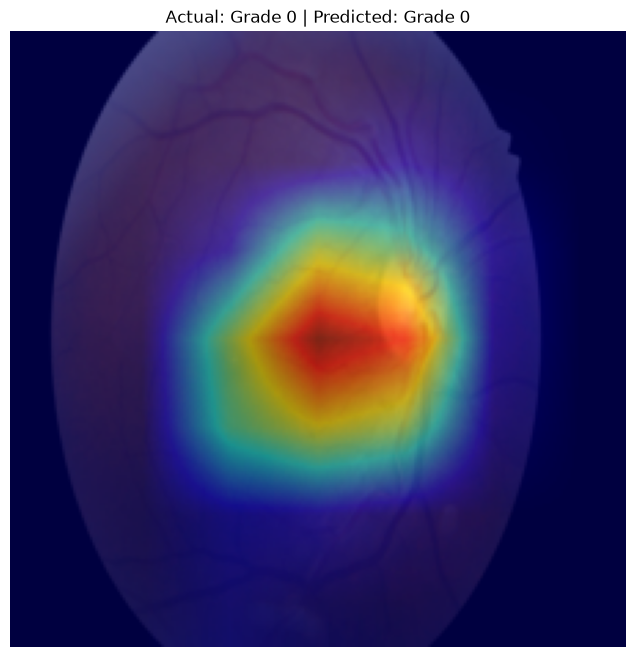

In [24]:
import numpy as np
import matplotlib.pyplot as plt

image, label = val_dataset[0]

input_tensor = image.unsqueeze(0).to(device)

output = model(input_tensor)
predicted_class = output.argmax(dim=1).item()

# Grad-CAM
grayscale_cam = cam(
    input_tensor=input_tensor,
    targets=[ClassifierOutputTarget(predicted_class)]
)[0]

# Convert image back for visualization
img = image.permute(1, 2, 0).cpu().numpy()

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

img = std * img + mean
img = np.clip(img, 0, 1)

visualization = show_cam_on_image(
    img,
    grayscale_cam,
    use_rgb=True
)

plt.figure(figsize=(8, 8))
plt.imshow(visualization)
plt.title(f"Actual: Grade {label} | Predicted: Grade {predicted_class}")
plt.axis("off")
plt.show()

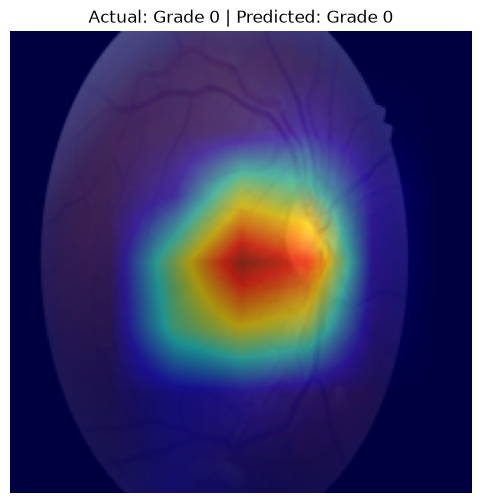

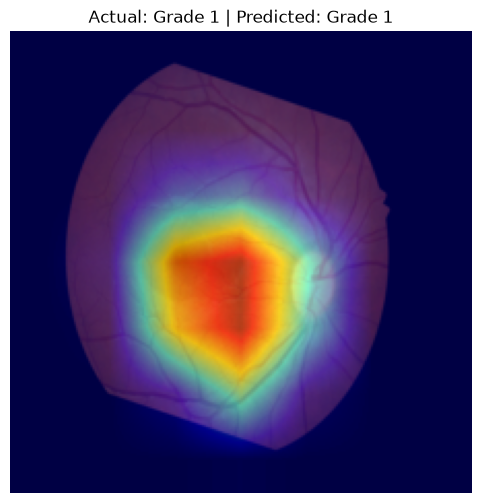

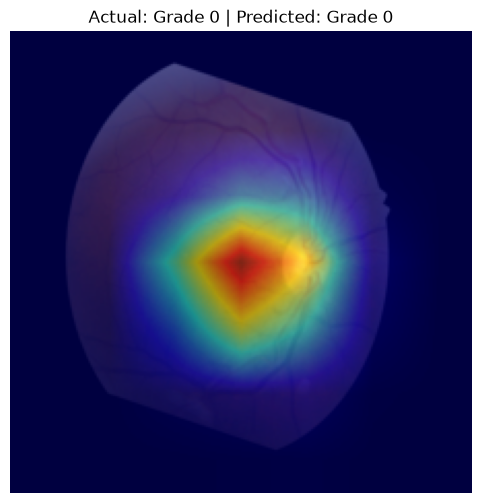

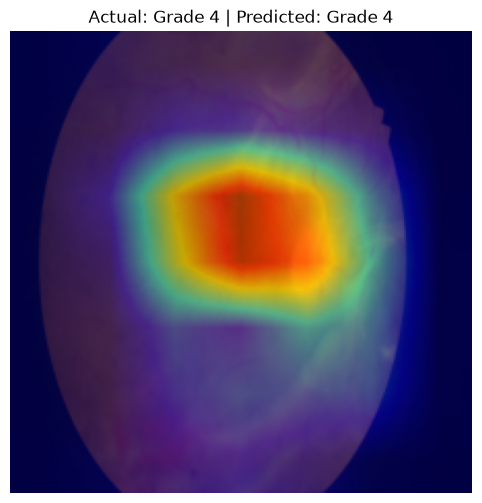

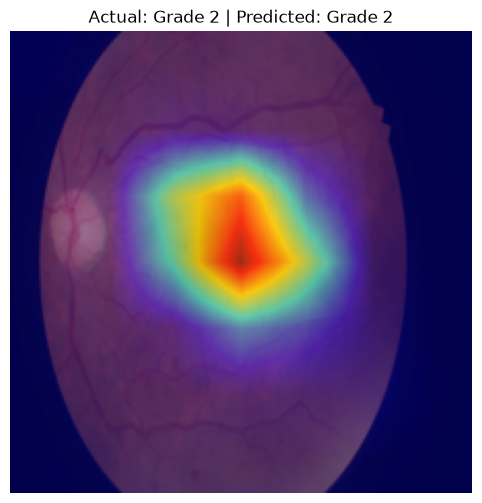

In [25]:
for idx in [0, 20, 50, 100, 150]:
    image, label = val_dataset[idx]

    input_tensor = image.unsqueeze(0).to(device)

    output = model(input_tensor)
    predicted_class = output.argmax(dim=1).item()

    grayscale_cam = cam(
        input_tensor=input_tensor,
        targets=[ClassifierOutputTarget(predicted_class)]
    )[0]

    img = image.permute(1, 2, 0).cpu().numpy()
    img = np.array([0.229, 0.224, 0.225]) * img + np.array([0.485, 0.456, 0.406])
    img = np.clip(img, 0, 1)

    visualization = show_cam_on_image(
        img,
        grayscale_cam,
        use_rgb=True
    )

    plt.figure(figsize=(6, 6))
    plt.imshow(visualization)
    plt.title(f"Actual: Grade {label} | Predicted: Grade {predicted_class}")
    plt.axis("off")
    plt.show()

In [26]:
from PIL import Image

def predict_image(image_path):
    image = Image.open(image_path).convert("RGB")
    image_tensor = val_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(image_tensor)
        probabilities = torch.softmax(output, dim=1)

    predicted_class = probabilities.argmax(dim=1).item()
    confidence = probabilities[0, predicted_class].item()

    return predicted_class, confidence

In [27]:
image_path = "IDRiD Dataset/Train/images/IDRiD_0001.jpg"

grade, confidence = predict_image(image_path)

print("Grade:", grade)
print("Confidence:", f"{confidence*100:.2f}%")

Grade: 0
Confidence: 99.86%
